# Loading and Pre-processsing the given data

In [100]:
words = open("./names.txt", "r").read().splitlines()
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [101]:
len(words)

32033

In [102]:
min_len_word = min(len(w) for w in words)
max_len_word = max(len(w) for w in words)
print(f"min_len_word: {min_len_word}, max_len_word:{max_len_word}")

min_len_word: 2, max_len_word:15


# Algo to make Bigram

In [103]:
# bigram
bigrams_counter = {}
for w in words:
    chs = ['<S>']+list(w)+['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1, ch2)
        bigrams_counter[bigram] = bigrams_counter.get(bigram, 0)+1


In [104]:
max(bc for bc in bigrams_counter.values())

6763

In [105]:
bigrams_counter.items()

dict_items([(('<S>', 'e'), 1531), (('e', 'm'), 769), (('m', 'm'), 168), (('m', 'a'), 2590), (('a', '<E>'), 6640), (('<S>', 'o'), 394), (('o', 'l'), 619), (('l', 'i'), 2480), (('i', 'v'), 269), (('v', 'i'), 911), (('i', 'a'), 2445), (('<S>', 'a'), 4410), (('a', 'v'), 834), (('v', 'a'), 642), (('<S>', 'i'), 591), (('i', 's'), 1316), (('s', 'a'), 1201), (('a', 'b'), 541), (('b', 'e'), 655), (('e', 'l'), 3248), (('l', 'l'), 1345), (('l', 'a'), 2623), (('<S>', 's'), 2055), (('s', 'o'), 531), (('o', 'p'), 95), (('p', 'h'), 204), (('h', 'i'), 729), (('<S>', 'c'), 1542), (('c', 'h'), 664), (('h', 'a'), 2244), (('a', 'r'), 3264), (('r', 'l'), 413), (('l', 'o'), 692), (('o', 't'), 118), (('t', 't'), 374), (('t', 'e'), 716), (('e', '<E>'), 3983), (('<S>', 'm'), 2538), (('m', 'i'), 1256), (('a', 'm'), 1634), (('m', 'e'), 818), (('<S>', 'h'), 874), (('r', 'p'), 14), (('p', 'e'), 197), (('e', 'r'), 1958), (('r', '<E>'), 1377), (('e', 'v'), 463), (('v', 'e'), 568), (('l', 'y'), 1588), (('y', 'n'), 18

# Building the bigram count matrix of given names.txt

In [106]:
import torch

In [107]:
# Allocating the bigram count matrix
N = torch.zeros(27,27, dtype=torch.int32)

In [108]:
# set of all chars used in names.txt - sorted
chars = sorted(set(list(''.join(words))))
chars

['a',
 'b',
 'c',
 'd',
 'e',
 'f',
 'g',
 'h',
 'i',
 'j',
 'k',
 'l',
 'm',
 'n',
 'o',
 'p',
 'q',
 'r',
 's',
 't',
 'u',
 'v',
 'w',
 'x',
 'y',
 'z']

In [109]:
char_to_int_map = {c:i+1 for i, c in enumerate(chars)}
char_to_int_map['.']=0 # special for end and start char
int_to_char_map = {i:c for c,i in char_to_int_map.items()}

In [110]:
# Building the bigram count matrix of given names.txt
for w in words:
    chs = ['.']+list(w)+['.']
    for c1, c2 in zip(chs,chs[1:]):
        i_c1 = char_to_int_map[c1]
        i_c2 = char_to_int_map[c2]
        N[i_c1,i_c2]+=1

N_COPY = N

(np.float64(-0.5), np.float64(26.5), np.float64(26.5), np.float64(-0.5))

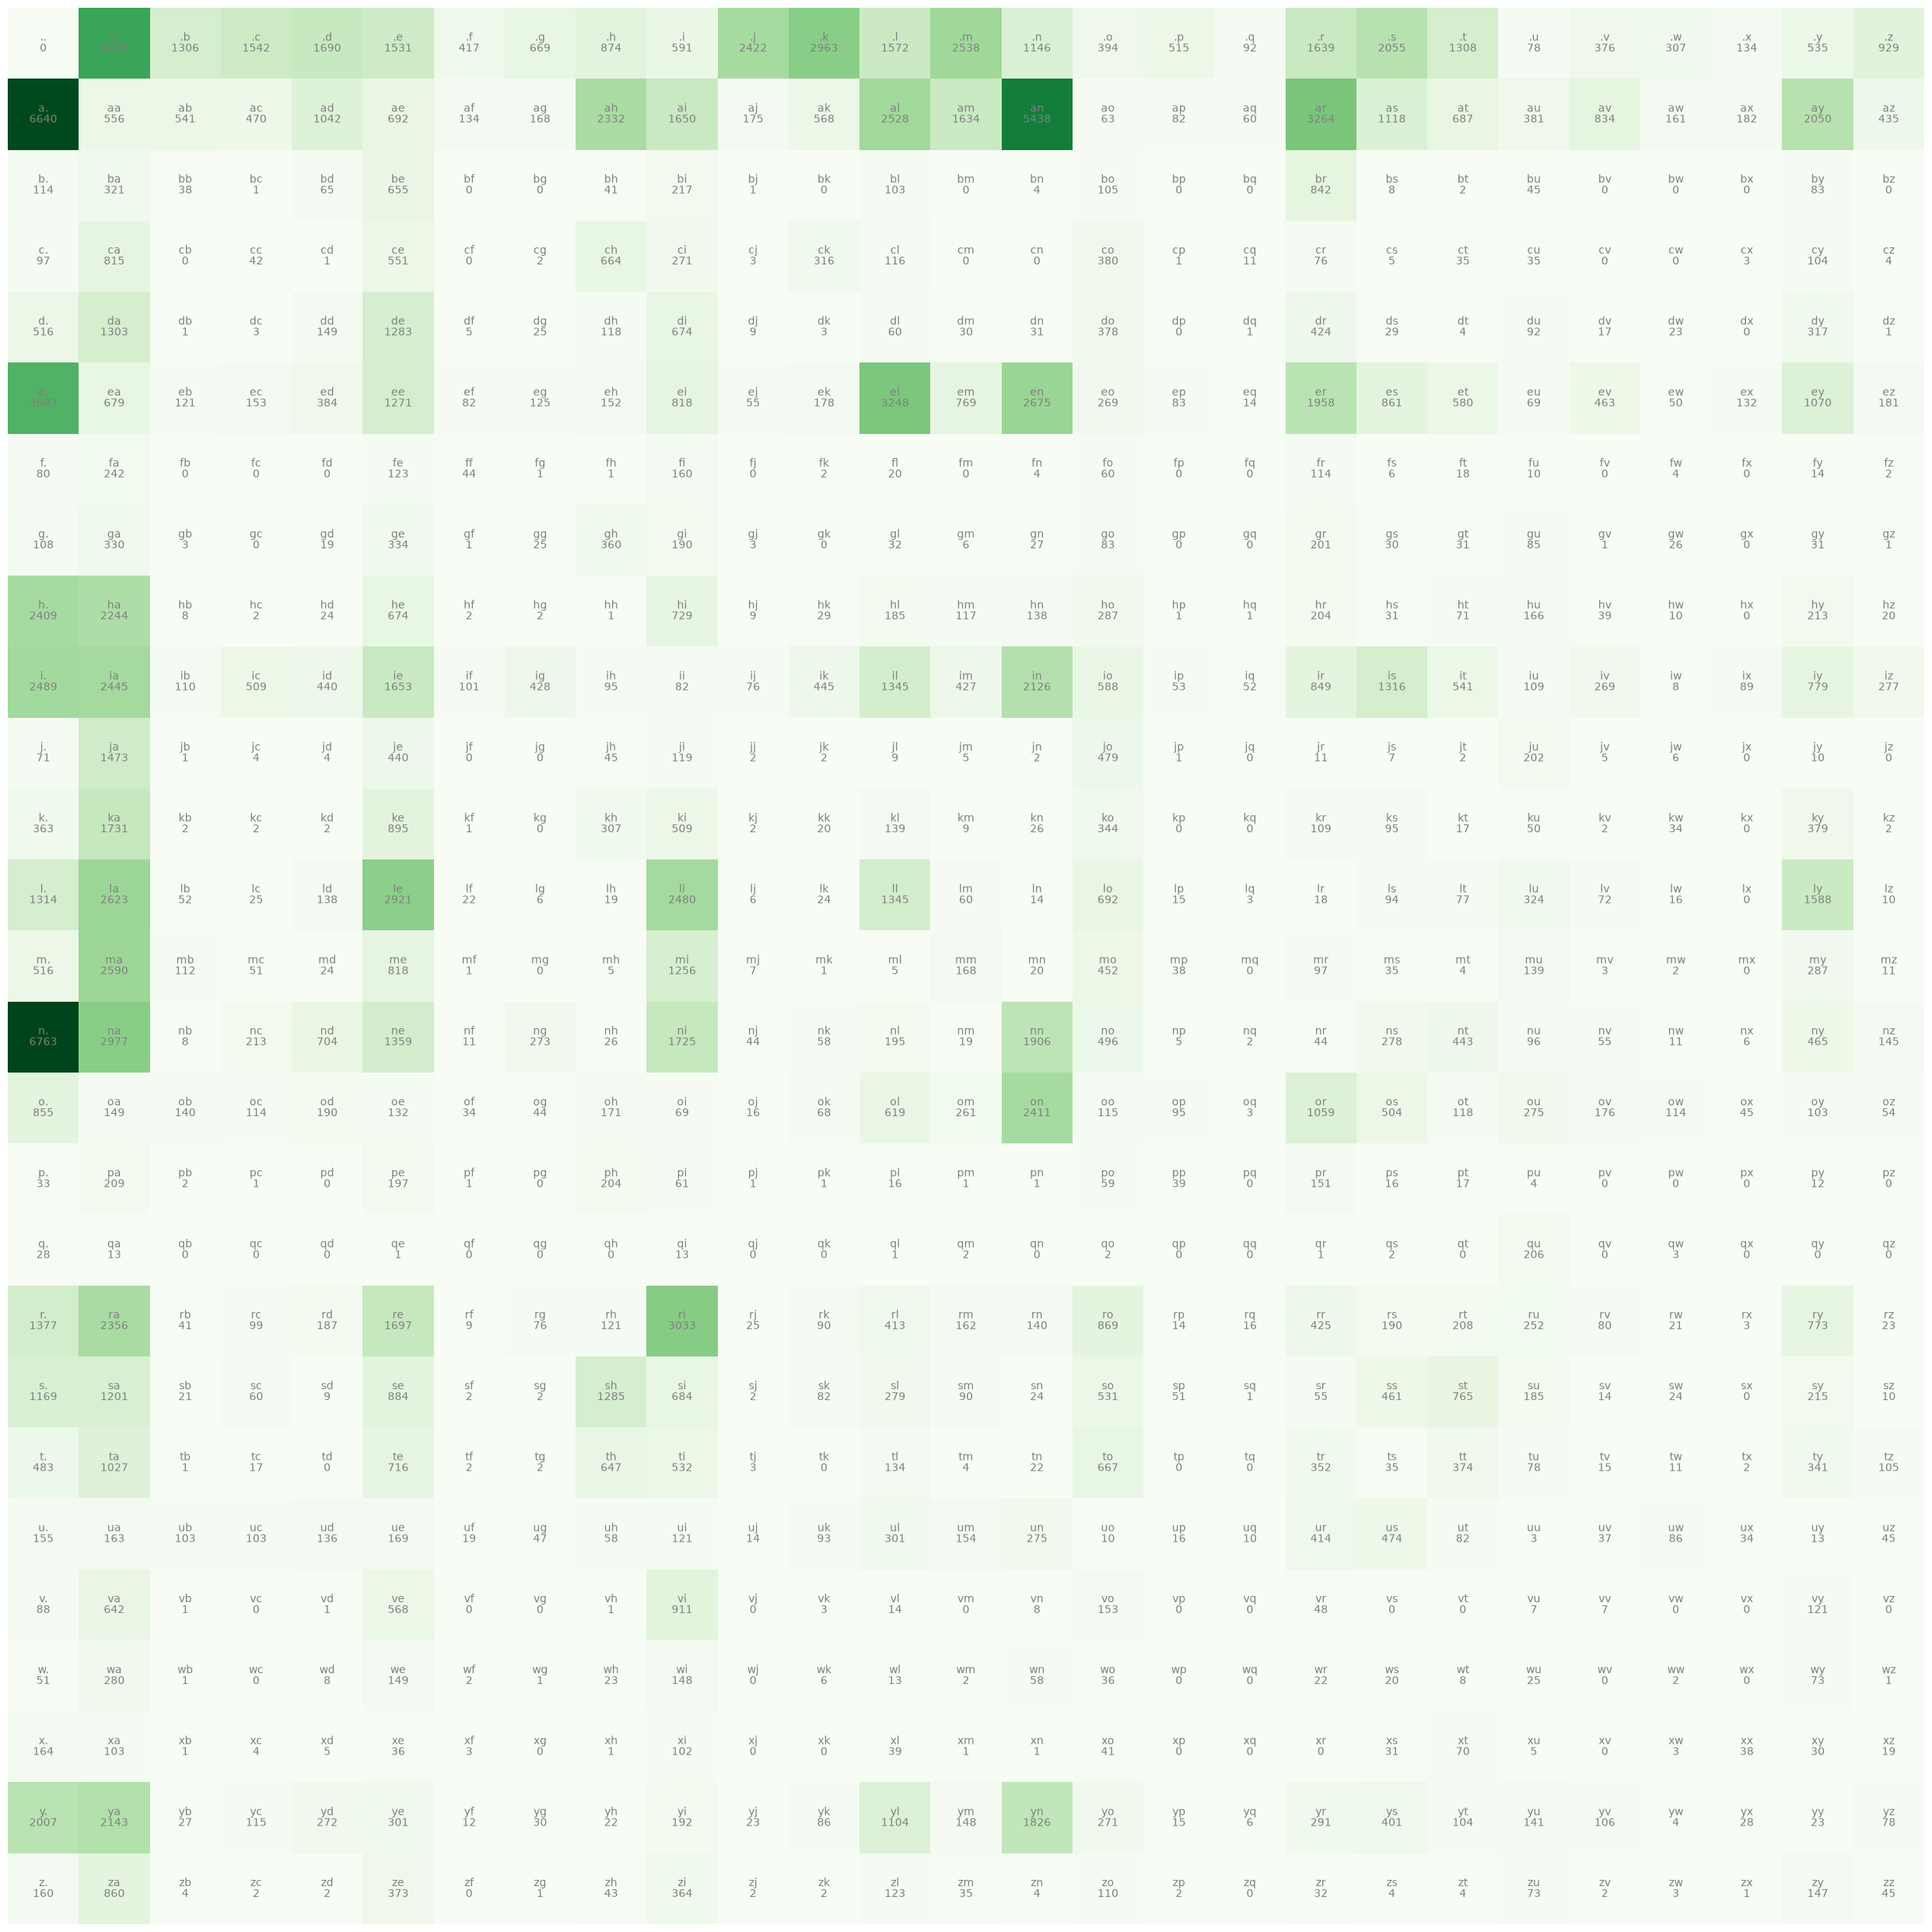

In [111]:
# Illustrating the bigram count matrix of given names.txt
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(32,32))
plt.imshow(N, cmap="Greens")

for i in range(27):
    for j in range(27):
        chstr = int_to_char_map[i]+int_to_char_map[j]
        plt.text(j,i, chstr, ha="center", va="bottom", color="gray")
        plt.text(j,i, N[i,j].item(), ha="center", va="top", color="gray")
plt.axis("off")

In [14]:
p = N[0].float()
p = p/p.sum()

print(p, p.sum())

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290]) tensor(1.)


In [113]:
# Random Seed and Generator
SEED = 2
g = torch.Generator().manual_seed(SEED)
for i in range(4):
    test_tensor_rand_value = torch.randint(-1,4,(4,), generator=g)
    print(f"iter {i}:: test_tensor_rand_value: {test_tensor_rand_value}")
    test_tensor_rand_value = test_tensor_rand_value/test_tensor_rand_value.sum()
    print(f"iter {i}:: normalized test_tensor_rand_value: {test_tensor_rand_value}\n")

iter 0:: test_tensor_rand_value: tensor([2, 1, 0, 3])
iter 0:: normalized test_tensor_rand_value: tensor([0.3333, 0.1667, 0.0000, 0.5000])

iter 1:: test_tensor_rand_value: tensor([ 2,  3,  1, -1])
iter 1:: normalized test_tensor_rand_value: tensor([ 0.4000,  0.6000,  0.2000, -0.2000])

iter 2:: test_tensor_rand_value: tensor([-1,  0, -1,  0])
iter 2:: normalized test_tensor_rand_value: tensor([0.5000, -0.0000, 0.5000, -0.0000])

iter 3:: test_tensor_rand_value: tensor([ 3, -1, -1,  2])
iter 3:: normalized test_tensor_rand_value: tensor([ 1.0000, -0.3333, -0.3333,  0.6667])



In [126]:
from torch.types import Tensor

def generate_name_randomly(how_many: int, Data:Tensor):
    g = torch.Generator().manual_seed(214483647)
    for i in range(how_many):
        ix = 0
        out = []
        while True:
            p = Data[ix].float()
            ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
            out.append(int_to_char_map[ix])
            if ix==0:
                break
        print(f"{i+1}. ", "".join(out))

generate_name_randomly(8, N)

1.  nina.
2.  jovyanieryn.
3.  jame.
4.  marillel.
5.  m.
6.  gronann.
7.  y.
8.  pan.


In [ ]:
""" 
MODEL SMOOTHING :
    since some of the bigram count is zero: which would lead to log(0) --> -infinite 
    We smooth the model by adding constant value to all parameters i.e. biagram counts
"""
N = N+1

tensor([[   2, 4412, 1308, 1544, 1692, 1533,  419,  671,  876,  593, 2424, 2965,
         1574, 2540, 1148,  396,  517,   94, 1641, 2057, 1310,   80,  378,  309,
          136,  537,  931],
        [6642,  558,  543,  472, 1044,  694,  136,  170, 2334, 1652,  177,  570,
         2530, 1636, 5440,   65,   84,   62, 3266, 1120,  689,  383,  836,  163,
          184, 2052,  437],
        [ 116,  323,   40,    3,   67,  657,    2,    2,   43,  219,    3,    2,
          105,    2,    6,  107,    2,    2,  844,   10,    4,   47,    2,    2,
            2,   85,    2],
        [  99,  817,    2,   44,    3,  553,    2,    4,  666,  273,    5,  318,
          118,    2,    2,  382,    3,   13,   78,    7,   37,   37,    2,    2,
            5,  106,    6],
        [ 518, 1305,    3,    5,  151, 1285,    7,   27,  120,  676,   11,    5,
           62,   32,   33,  380,    2,    3,  426,   31,    6,   94,   19,   25,
            2,  319,    3],
        [3985,  681,  123,  155,  386, 1273,   84,

In [137]:
P = N.float()
P /= P.sum(1, keepdim=True)

In [139]:
generate_name_randomly(5, P)

1.  nina.
2.  jovyanieryn.
3.  jame.
4.  marillel.
5.  m.


In [145]:
""" MEASURING LOSS or QUALITY OF MODEL 

    - the product of all probabilities of biagrams is Likelikhood Estimation
    - then log(likelihood) since log func is monotonic - will always give -ve num to -infinite
    - so taking -ve of log(likelihood) is :: Negative Log Likelihood (NLL) -> give the loss of model 
    
    -> Maxiumizing the Likelihood is minizmize the NLL which is loss of model :: ulitmately
    increasing the quality of this model 
    
Maths:

    likelihood = a*b*c ; where a, b, c are probabilities
    
    log(likelihood) = log(a*b*c) = log(a) + log(b) + log(c)
"""
log_likelihood = 0.0
n = 0
for w in words[:4]:
    for ch1, ch2 in zip(w, w[1:]):
        ix1 = char_to_int_map[ch1]
        ix2 = char_to_int_map[ch2]
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        n +=1
        print(f"{ch1} -> {ch2} -- prob: {prob}, logprob: {logprob}")
        
print("\nQUALITY OF MODEL")
nll = - log_likelihood # negative log_likelihood (NLL)
print(f"Negative log likelihood -> {nll=}")
avg_nll = nll/n
print(f"ave of NLL :: loss of model -> {avg_nll=}")
        

e -> m -- prob: 0.03765200078487396, logprob: -3.2793691158294678
m -> m -- prob: 0.025388291105628014, logprob: -3.6734671592712402
m -> a -- prob: 0.3870967626571655, logprob: -0.9490805864334106
o -> l -- prob: 0.07774161547422409, logprob: -2.5543646812438965
l -> i -- prob: 0.17713388800621033, logprob: -1.7308493852615356
i -> v -- prob: 0.015263305976986885, logprob: -4.182303428649902
v -> i -- prob: 0.34754472970962524, logprob: -1.0568618774414062
i -> a -- prob: 0.13782033324241638, logprob: -1.981804370880127
a -> v -- prob: 0.024632427841424942, logprob: -3.7036914825439453
v -> a -- prob: 0.24514655768871307, logprob: -1.4058990478515625
i -> s -- prob: 0.07423260807991028, logprob: -2.6005518436431885
s -> a -- prob: 0.14742647111415863, logprob: -1.9144257307052612
a -> b -- prob: 0.015999292954802513, logprob: -4.1352105140686035
b -> e -- prob: 0.2434234917163849, logprob: -1.4129525423049927
e -> l -- prob: 0.1587146520614624, logprob: -1.8406473398208618
l -> l -- p

# Training the bigarm in NN (neural network)



In [146]:
# create the training set of bigrams (x, y)

xs, ys = [], []

for w in words[:1]:
    chs = ["."]+list(w)+["."]
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = char_to_int_map[ch1]
        ix2 = char_to_int_map[ch2]
        print(f"{ch1} -> {ch2}")
        xs.append(ix1)
        ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)

. -> e
e -> m
m -> m
m -> a
a -> .


In [149]:
xs

tensor([ 0,  5, 13, 13,  1])

In [150]:
ys

tensor([ 5, 13, 13,  1,  0])

In [ ]:
W = torch.randn((27,27), generator=g)


In [162]:
# one hot encoding 
xenc = torch.nn.functional.one_hot(xs, num_classes=27).float() # inputs to the NN; one hot encoding
logits = xenc @ W # predict log counts 
counts = logits.exp() # counts, equivalent to N 
probs = counts/counts.sum(1, keepdim=True)

In [165]:
probs

tensor([[0.0201, 0.0196, 0.0151, 0.0084, 0.0101, 0.0343, 0.0192, 0.0483, 0.0234,
         0.0523, 0.0383, 0.0273, 0.0144, 0.0062, 0.0241, 0.0097, 0.0093, 0.0245,
         0.0598, 0.0427, 0.0092, 0.0929, 0.0287, 0.0351, 0.0611, 0.2437, 0.0224],
        [0.0212, 0.0224, 0.0062, 0.0297, 0.0142, 0.0339, 0.0858, 0.0426, 0.0329,
         0.0476, 0.1304, 0.0598, 0.0620, 0.0110, 0.0257, 0.0220, 0.0235, 0.0153,
         0.0451, 0.0312, 0.0229, 0.0680, 0.0486, 0.0234, 0.0221, 0.0422, 0.0105],
        [0.0093, 0.0785, 0.0329, 0.0144, 0.1052, 0.0511, 0.0123, 0.0032, 0.0441,
         0.0094, 0.0055, 0.0341, 0.0090, 0.0095, 0.0179, 0.0784, 0.2130, 0.0373,
         0.0183, 0.0052, 0.0101, 0.1012, 0.0565, 0.0029, 0.0173, 0.0098, 0.0135],
        [0.0093, 0.0785, 0.0329, 0.0144, 0.1052, 0.0511, 0.0123, 0.0032, 0.0441,
         0.0094, 0.0055, 0.0341, 0.0090, 0.0095, 0.0179, 0.0784, 0.2130, 0.0373,
         0.0183, 0.0052, 0.0101, 0.1012, 0.0565, 0.0029, 0.0173, 0.0098, 0.0135],
        [0.0424, 0.0187,

In [166]:
probs.shape

torch.Size([5, 27])